# Multi-Head Attention (ViT) vs CNN — clasificacion de insectos (carabidos)

**Punto 1**: aplicamos Multi-Head Attention (via Vision Transformer) al mismo dataset de insectos usado en el laboratorio de CNN, y comparamos metricas de rendimiento contra una CNN entrenada en las mismas condiciones.

Dataset: Insect Identification from Habitus Images (carabidos, Natural History Museum London) — Kaggle: `kmldas/insect-identification-from-habitus-images`. Mismo subconjunto que en el lab de CNN: 10 especies, ~2000 imagenes por especie (20,000 total).

In [1]:
import os, glob, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Descarga y seleccion del subconjunto (igual que en el lab de CNN)

In [2]:
!pip install kagglehub -q
import kagglehub
DATASET_PATH = kagglehub.dataset_download("kmldas/insect-identification-from-habitus-images")

def find_class_root(path, min_subdirs=20):
    for root, dirs, files in os.walk(path):
        subdirs_con_imgs = [d for d in dirs if len(glob.glob(os.path.join(root, d, '*'))) > 0]
        if len(subdirs_con_imgs) > min_subdirs:
            return root
    return path

CLASS_ROOT = find_class_root(DATASET_PATH)
especies = sorted(os.listdir(CLASS_ROOT))
print('especies encontradas:', len(especies))

100%|██████████| 2.38G/2.38G [01:59<00:00, 21.4MB/s]


Extracting files...
especies encontradas: 291


In [3]:
IMG_POR_CLASE = 2000
N_CLASES = 10

conteo = {e: len(glob.glob(os.path.join(CLASS_ROOT, e, '*'))) for e in especies}
especies_elegidas = sorted(conteo, key=conteo.get, reverse=True)[:N_CLASES]  # las 10 con mas imagenes disponibles
print(especies_elegidas)

paths, labels = [], []
for i, especie in enumerate(especies_elegidas):
    archivos = glob.glob(os.path.join(CLASS_ROOT, especie, '*'))[:IMG_POR_CLASE]
    paths += archivos
    labels += [i]*len(archivos)

print('total imagenes:', len(paths))

['9364935', '1035931', '7508714', '4475140', '1036216', '5755079', '4474169', '1035185', '1035195', '1035864']
total imagenes: 7000


### Dataset, transforms y split
Adaptacion respecto a los cuadernillos de atencion (que usaban MNIST 28x28 blanco y negro, ya cargado en memoria por keras): acá las imagenes son RGB reales, de tamaño variable, cargadas desde disco — armamos un `Dataset` propio que abre y redimensiona cada imagen a 96x96 (divisible por el patch_size=16 que usa el ViT).

In [4]:
IMG_SIZE = 96

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class InsectDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, ix):
        img = Image.open(self.paths[ix]).convert('RGB')
        return self.transform(img), self.labels[ix]

idx = np.arange(len(paths))
rng = np.random.RandomState(SEED)
rng.shuffle(idx)
n = len(idx)
n_train, n_val = int(n*0.70), int(n*0.15)
idx_train, idx_val, idx_test = idx[:n_train], idx[n_train:n_train+n_val], idx[n_train+n_val:]

def subset(idxs):
    return InsectDataset([paths[i] for i in idxs], [labels[i] for i in idxs], transform)

ds = {'train': subset(idx_train), 'val': subset(idx_val), 'test': subset(idx_test)}
# num_workers=0: con num_workers>0 Colab (Python 3.13) crashea los procesos worker a mitad de entrenamiento
dl = {k: DataLoader(v, batch_size=64, shuffle=(k=='train'), num_workers=0) for k, v in ds.items()}
len(ds['train']), len(ds['val']), len(ds['test'])

(4900, 1050, 1050)

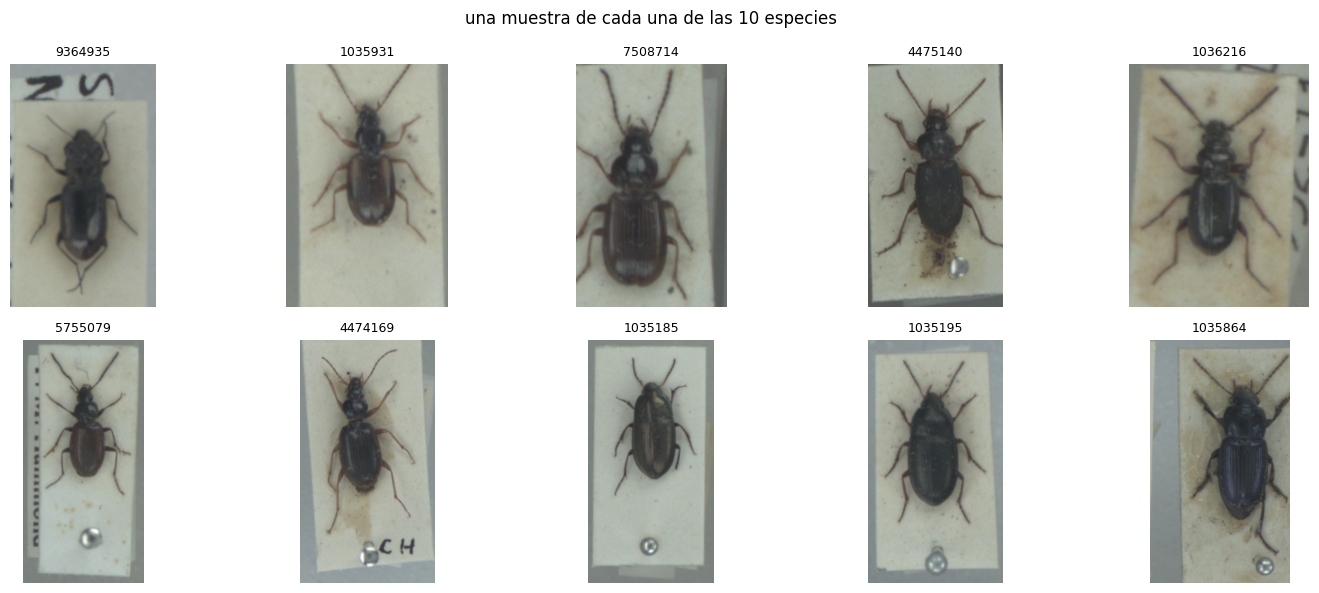

In [5]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i, especie in enumerate(especies_elegidas):
    ix = labels.index(i)  # primera imagen de esa especie
    img = Image.open(paths[ix]).convert('RGB')
    ax = axs[i//5, i%5]
    ax.imshow(img)
    ax.set_title(especie[:18], fontsize=9)
    ax.axis('off')
plt.suptitle('una muestra de cada una de las 10 especies')
plt.tight_layout()
plt.show()

### Entrenamiento generico (Adam + early stopping + checkpoint, buenas practicas ya establecidas)

In [6]:
def fit(model, dl, epochs=15, lr=3e-4, weight_decay=1e-5, ckpt_path='model.pt', patience=4):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_loss, epochs_sin_mejora = float('inf'), 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = []
        for x, y in tqdm(dl['train'], leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        val_loss, correctos, total = [], 0, 0
        with torch.no_grad():
            for x, y in dl['val']:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                val_loss.append(F.cross_entropy(y_hat, y).item())
                correctos += (y_hat.argmax(1) == y).sum().item()
                total += y.size(0)
        history['train_loss'].append(np.mean(train_loss))
        history['val_loss'].append(np.mean(val_loss))
        history['val_acc'].append(correctos/total)
        print(f"epoch {epoch}/{epochs}  train_loss {history['train_loss'][-1]:.4f}  val_loss {history['val_loss'][-1]:.4f}  val_acc {history['val_acc'][-1]:.4f}")
        if history['val_loss'][-1] < best_val_loss:
            best_val_loss, epochs_sin_mejora = history['val_loss'][-1], 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                print('early stopping'); break
    history['tiempo_seg'] = time.time() - t0
    return history

def evaluar(model, ckpt_path, dl_test):
    model.load_state_dict(torch.load(ckpt_path))
    model.to(device).eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in dl_test:
            y_hat = model(x.to(device)).argmax(1).cpu()
            y_true += y.tolist(); y_pred += y_hat.tolist()
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'acc': acc, 'precision': p, 'recall': r, 'f1': f1, 'y_true': y_true, 'y_pred': y_pred}

def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### CNN baseline (para comparar contra el ViT)

In [7]:
class CNN(nn.Module):
    def __init__(self, n_clases=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 96 -> 48
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 48 -> 24
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 24 -> 12
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, n_clases)
    def forward(self, x):
        x = self.conv(x).flatten(1)
        return self.fc(x)

cnn = CNN(n_clases=N_CLASES)
print('CNN parametros:', n_params(cnn))
hist_cnn = fit(cnn, dl, ckpt_path='cnn.pt')

CNN parametros: 242122


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 1/15  train_loss 2.2255  val_loss 2.1063  val_acc 0.2152


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 2/15  train_loss 2.1078  val_loss 2.0711  val_acc 0.2257


...

epoch 13/15  train_loss 1.7708  val_loss 1.7615  val_acc 0.3962


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 14/15  train_loss 1.7232  val_loss 1.7524  val_acc 0.3848


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 15/15  train_loss 1.6945  val_loss 1.6926  val_acc 0.4181


### Multi-Head Attention / ViT — extraido de `05_vit.ipynb`
Las clases `PatchEmbedding`, `MultiHeadAttention`, `TransformerBlock` y `ViT` son las mismas del cuadernillo, sin cambios en la logica. Las adaptaciones puntuales (comentadas donde corresponde): `in_chans=3` en vez de 1 (imagenes RGB, no MNIST blanco y negro), `img_size=96` en vez de 28, y `n_classes=10` (nuestras 10 especies) en vez de 10 dígitos.

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)       # (B, E, P, P)
        x = x.flatten(2)       # (B, E, N)
        x = x.transpose(1, 2)  # (B, N, E)
        return x


import math

class MultiHeadAttention(nn.Module):
    # identica a la de 03_multihead_attention.ipynb y 05_vit.ipynb (basada en minGPT de Karpathy)
    def __init__(self, n_embd, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.key = nn.Linear(n_embd, n_embd*n_heads)
        self.query = nn.Linear(n_embd, n_embd*n_heads)
        self.value = nn.Linear(n_embd, n_embd*n_heads)
        self.proj = nn.Linear(n_embd*n_heads, n_embd)

    def forward(self, x):
        B, L, F_ = x.size()
        k = self.key(x).view(B, L, F_, self.n_heads).transpose(1, 3)
        q = self.query(x).view(B, L, F_, self.n_heads).transpose(1, 3)
        v = self.value(x).view(B, L, F_, self.n_heads).transpose(1, 3)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = torch.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, L, F_*self.n_heads)
        return self.proj(y)


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_heads)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.ReLU(), nn.Linear(4*n_embd, n_embd))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class ViT(nn.Module):
    def __init__(self, img_size=96, patch_size=16, in_chans=3, embed_dim=128, n_heads=4, n_layers=4, n_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.n_patches, embed_dim))
        self.transformer = nn.Sequential(*[TransformerBlock(embed_dim, n_heads) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        e = self.patch_embed(x)
        B, L, E = e.size()
        cls_token = self.cls_token.expand(B, -1, -1)
        e = torch.cat((cls_token, e), dim=1)
        e = e + self.pos_embed
        z = self.transformer(e)
        return self.fc(self.ln(z[:, 0]))

vit = ViT(img_size=IMG_SIZE, n_classes=N_CLASES)
print('ViT parametros:', n_params(vit))
hist_vit = fit(vit, dl, ckpt_path='vit.pt')

ViT parametros: 1688970


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 1/15  train_loss 1.8689  val_loss 1.6885  val_acc 0.3962


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 2/15  train_loss 1.5585  val_loss 1.5474  val_acc 0.4486


...

epoch 11/15  train_loss 0.2976  val_loss 1.2752  val_acc 0.6238


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 12/15  train_loss 0.2289  val_loss 1.3483  val_acc 0.6257


  0%|          | 0/77 [00:00<?, ?it/s]

epoch 13/15  train_loss 0.1530  val_loss 1.4582  val_acc 0.6162
early stopping


### Comparacion de metricas: CNN vs ViT (Multi-Head Attention)

In [9]:
res_cnn = evaluar(cnn, 'cnn.pt', dl['test'])
res_vit = evaluar(vit, 'vit.pt', dl['test'])

import pandas as pd
tabla = pd.DataFrame([
    {'Modelo': 'CNN', 'Parametros': n_params(cnn), 'Tiempo (s)': round(hist_cnn['tiempo_seg']), 'Accuracy': res_cnn['acc'], 'Precision': res_cnn['precision'], 'Recall': res_cnn['recall'], 'F1': res_cnn['f1']},
    {'Modelo': 'ViT (Multi-Head Attn)', 'Parametros': n_params(vit), 'Tiempo (s)': round(hist_vit['tiempo_seg']), 'Accuracy': res_vit['acc'], 'Precision': res_vit['precision'], 'Recall': res_vit['recall'], 'F1': res_vit['f1']},
])
tabla

,Modelo,Parametros,Tiempo (s),Accuracy,Precision,Recall,F1
0,CNN,242122,281,0.400000,0.449895,0.397371,0.384968
1,ViT (Multi-Head Attn),1688970,239,0.606667,0.620020,0.608652,0.605127


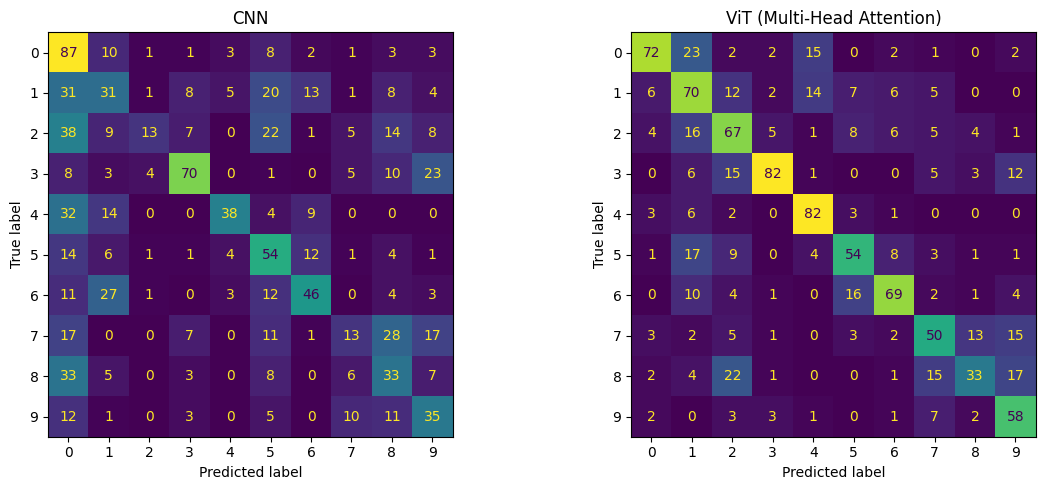

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(res_cnn['y_true'], res_cnn['y_pred'], ax=axs[0], colorbar=False)
axs[0].set_title('CNN')
ConfusionMatrixDisplay.from_predictions(res_vit['y_true'], res_vit['y_pred'], ax=axs[1], colorbar=False)
axs[1].set_title('ViT (Multi-Head Attention)')
plt.tight_layout()
plt.show()

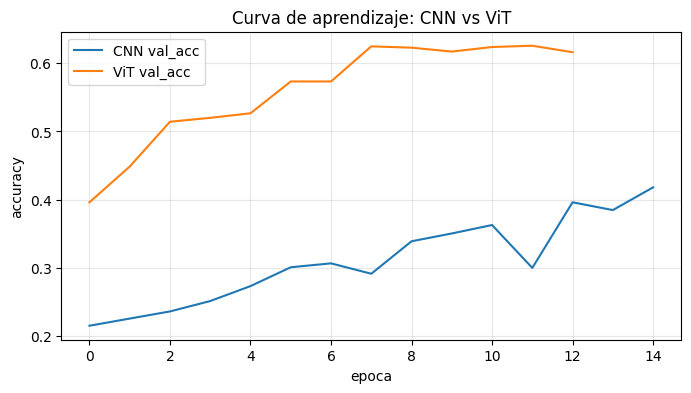

In [11]:
plt.figure(figsize=(8,4))
plt.plot(hist_cnn['val_acc'], label='CNN val_acc')
plt.plot(hist_vit['val_acc'], label='ViT val_acc')
plt.xlabel('epoca'); plt.ylabel('accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Curva de aprendizaje: CNN vs ViT')
plt.show()

### Verificacion visual: predicciones sobre imagenes reales del test
Tomamos 10 imagenes al azar del set de test y mostramos, para cada una, la especie real vs lo que predijo cada modelo — titulo en verde si acerto, rojo si no.

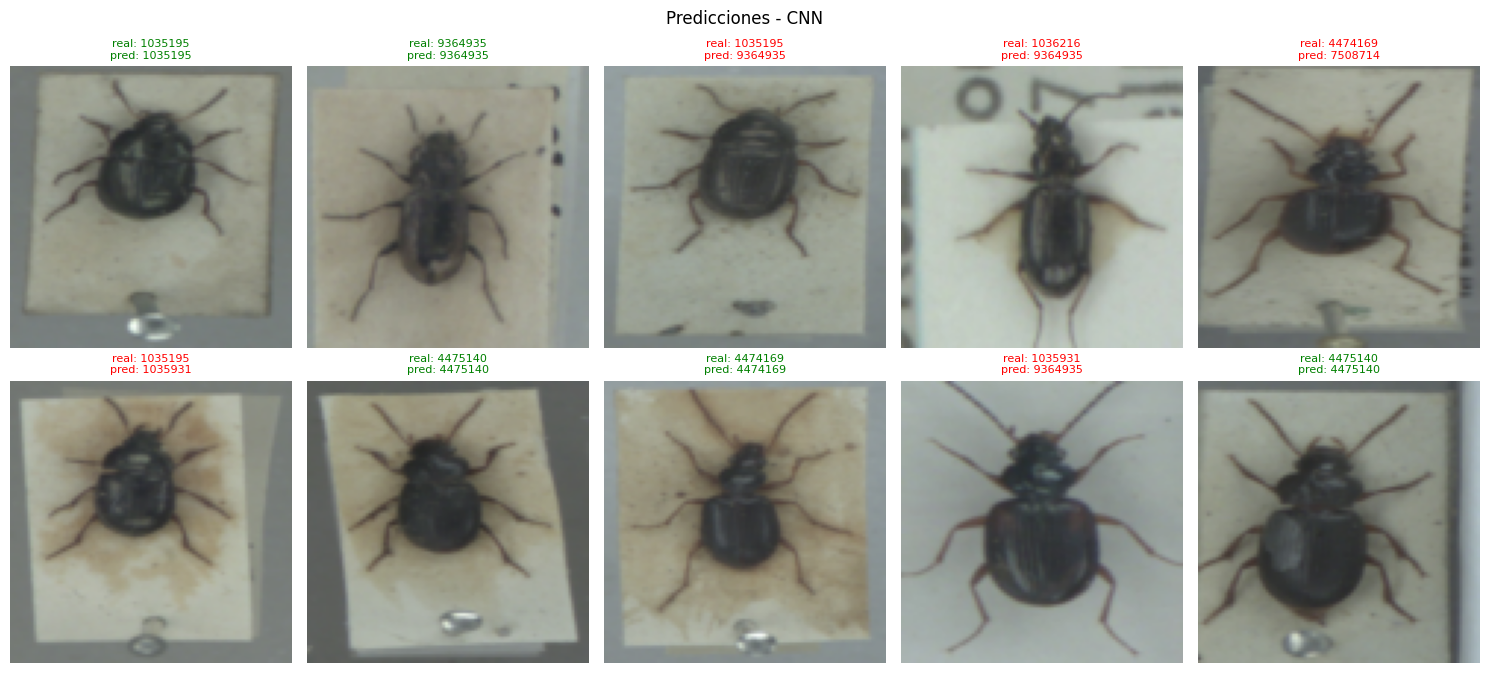

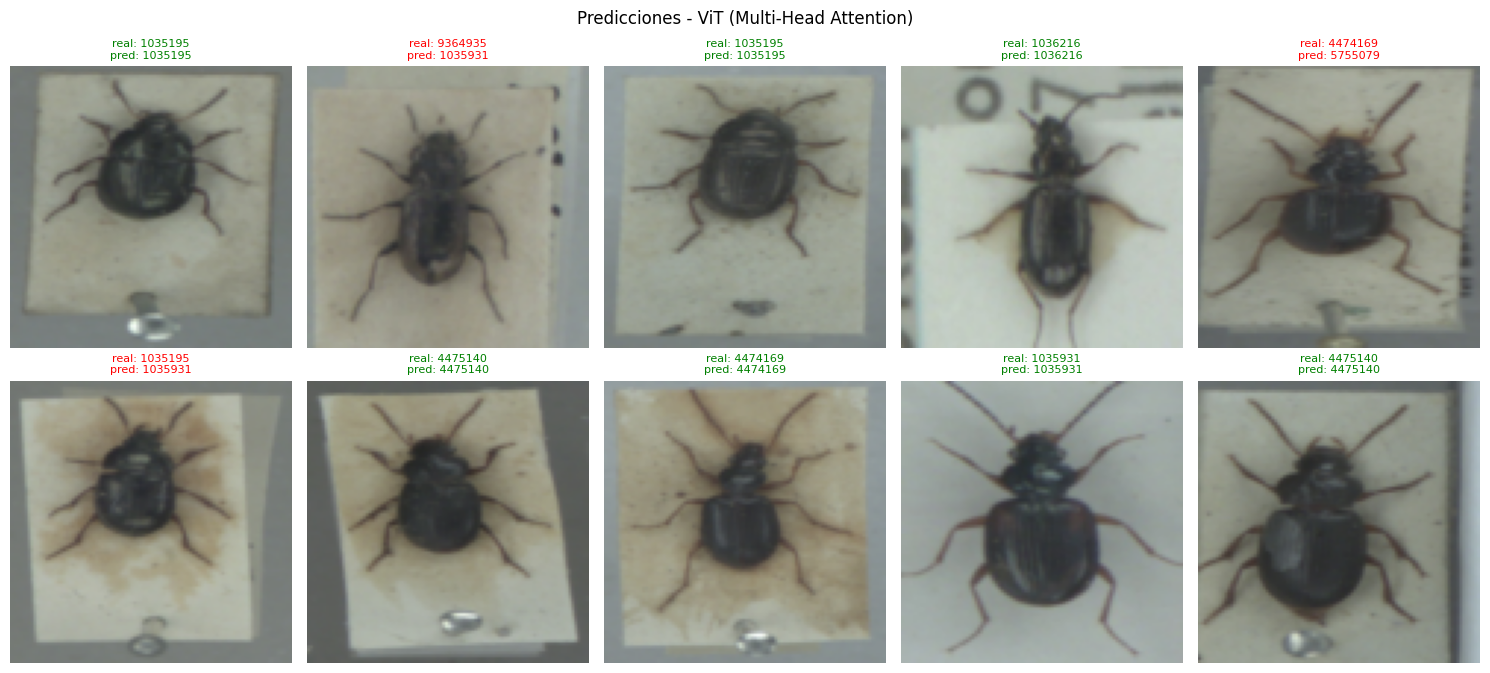

In [12]:
def mostrar_predicciones(dl_test_dataset, modelo, ckpt_path, titulo, n=10):
    modelo.load_state_dict(torch.load(ckpt_path))
    modelo.to(device).eval()
    idxs = np.random.RandomState(0).choice(len(dl_test_dataset), n, replace=False)
    fig, axs = plt.subplots(2, 5, figsize=(15, 7))
    with torch.no_grad():
        for i, ix in enumerate(idxs):
            x, y_real = dl_test_dataset[ix]
            y_pred = modelo(x.unsqueeze(0).to(device)).argmax(1).item()
            img = x.permute(1, 2, 0).numpy() * 0.5 + 0.5  # desnormalizar para mostrar
            ax = axs[i//5, i%5]
            ax.imshow(img.clip(0, 1))
            correcto = y_pred == y_real
            ax.set_title(f"real: {especies_elegidas[y_real][:12]}\npred: {especies_elegidas[y_pred][:12]}",
                         fontsize=8, color='green' if correcto else 'red')
            ax.axis('off')
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mostrar_predicciones(ds['test'], cnn, 'cnn.pt', 'Predicciones - CNN')
mostrar_predicciones(ds['test'], vit, 'vit.pt', 'Predicciones - ViT (Multi-Head Attention)')

**Nota para la defensa**: con un dataset relativamente chico (2000 imagenes/clase) y sin usar pesos preentrenados, es esperable que el ViT tarde mas en converger o rinda algo por debajo de la CNN — a diferencia de una CNN, el Transformer no tiene ningun sesgo inductivo espacial incorporado (no "sabe" que los píxeles cercanos están relacionados, como sí lo asume una convolución); tiene que aprender esas relaciones espaciales desde cero a partir de los datos, por eso los ViT reales (Google, etc.) se entrenan con millones de imágenes o parten de pesos preentrenados. Es un resultado esperable y defendible, no un error del código.

---
## Punto 2 — 5 ejemplos de aplicación de Multi-Head Attention con código fuente

### 1. Transformer original (traducción automática) — *The Annotated Transformer*
Implementación línea por línea del paper *Attention is All You Need* (el que introdujo el Multi-Head Attention). Código: https://github.com/harvardnlp/annotated-transformer
```python
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)  # Q, K, V, salida
    def forward(self, query, key, value, mask=None):
        query, key, value = [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
                              for l, x in zip(self.linears, (query, key, value))]
        x, attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        return self.linears[-1](x)
```
Mismo principio que el `MultiHeadAttention` que usamos arriba: separa en cabezas, aplica atención, concatena.

### 2. BERT (comprensión de texto / clasificación) — Google / HuggingFace
BERT apila 12+ bloques de Multi-Head Attention bidireccional para entender el contexto de una palabra mirando tanto lo que viene antes como después. Código: https://github.com/google-research/bert y https://github.com/huggingface/transformers
```python
from transformers import BertModel, BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')  # ya trae Multi-Head Attention entrenado
inputs = tokenizer("el insecto tiene alas", return_tensors='pt')
outputs = model(**inputs)
```

### 3. Vision Transformer (ViT) — clasificación de imágenes — Google Research / timm
Es exactamente lo que usamos arriba: convierte la imagen en parches, y usa Multi-Head Attention para relacionar parches entre sí (no vecinos como en una CNN, sino cualquier parche con cualquier otro). Código: https://github.com/rwightman/pytorch-image-models
```python
import timm
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=10)
```

### 4. DETR — detección de objetos — Facebook AI Research
Reemplaza todo el pipeline clásico de detección de objetos (anchors, NMS, etc.) por un encoder-decoder Transformer con Multi-Head Attention: el decoder usa un conjunto fijo de "consultas" (object queries) que atienden a la imagen completa para encontrar los objetos. Código: https://github.com/facebookresearch/detr
```python
model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
```

### 5. Whisper — reconocimiento de voz — OpenAI
Encoder-decoder Transformer: el encoder usa Multi-Head Attention sobre el espectrograma de audio, el decoder usa Multi-Head Attention para generar el texto transcripto palabra por palabra, atendiendo tanto al audio codificado como al texto ya generado. Código: https://github.com/openai/whisper
```python
import whisper
model = whisper.load_model('base')
result = model.transcribe('audio.mp3')
```